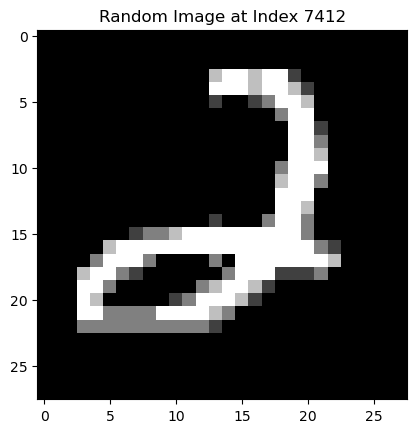

In [2]:
import pandas as pd
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST CSV
file_path = "mnist_test.csv"  # Replace with your actual file path
mnist_data = pd.read_csv(file_path)

# Choose a random row index (skip the first column, which is the label
random_index = np.random.randint(0, len(mnist_data))  # Random index from 0 to len(dataset)-1

# Extract the selected row and reshape it to 28x28
random_image = mnist_data.iloc[random_index, 1:].values.reshape(28, 28).astype(np.uint8)  # Skip label column

# Convert to Pillow Image
img = Image.fromarray(random_image)

# Display the Random Image
plt.imshow(img, cmap="gray")
plt.title(f"Random Image at Index {random_index}")
plt.show()

/var/folders/t4/q45vqnlj5v14zpkyt10s17tm0000gn/T/ipykernel_7282/3779273309.py:15: RuntimeWarning: divide by zero encountered in log
  log_transformed = (c * np.log(1 + image)).astype(np.uint8)
/var/folders/t4/q45vqnlj5v14zpkyt10s17tm0000gn/T/ipykernel_7282/3779273309.py:15: RuntimeWarning: invalid value encountered in cast
  log_transformed = (c * np.log(1 + image)).astype(np.uint8)


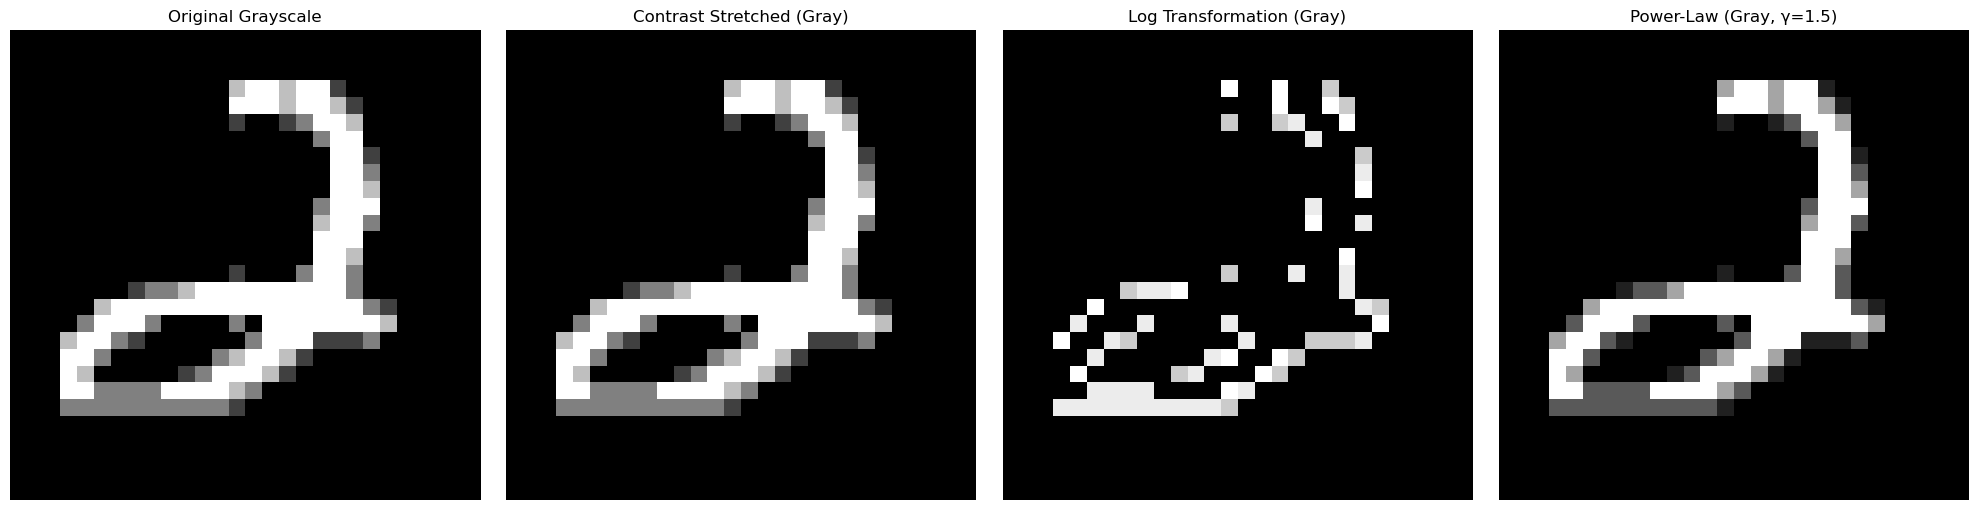

In [3]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Contrast Stretching
def contrast_stretching(image):
    min_val = np.min(image)
    max_val = np.max(image)
    stretched = ((image - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    return stretched

# 2. Log Transformation
def log_transformation(image):
    c = 255 / np.log(1 + np.max(image))
    log_transformed = (c * np.log(1 + image)).astype(np.uint8)
    return log_transformed

# 3. Power-Law (Gamma) Transformation
def power_law_transformation(image, gamma=1.5):
    normalized = image / 255.0  # Normalize to range [0, 1]
    power_transformed = (255 * (normalized ** gamma)).astype(np.uint8)
    return power_transformed

# Apply the transformations on grayscale image
contrast_gray = contrast_stretching(random_image)
log_gray = log_transformation(random_image)
power_gray = power_law_transformation(random_image, gamma=1.5)

# Plot the results for grayscale
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(random_image, cmap="gray")
axes[0].set_title("Original Grayscale")
axes[0].axis("off")

axes[1].imshow(contrast_gray, cmap="gray")
axes[1].set_title("Contrast Stretched (Gray)")
axes[1].axis("off")

axes[2].imshow(log_gray, cmap="gray")
axes[2].set_title("Log Transformation (Gray)")
axes[2].axis("off")

axes[3].imshow(power_gray, cmap="gray")
axes[3].set_title("Power-Law (Gray, γ=1.5)")
axes[3].axis("off")
plt.tight_layout()
plt.show()